# Question 5: Granger Causality and Price Discovery

**Objective:** Investigate the direction of information flows across five asset classes using Granger Causality tests to improve forecasting and hedging strategies.

**Assets:**
1.  Equity Index (S&P 500)
2.  Government Bond Yield (US 10Y)
3.  Corporate Bond Spread (US Corp OAS)
4.  Commodity (Brent Oil)
5.  Exchange Rate (USD/JPY)

**Data Frequency:** Weekly (2000-2025)


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1338 entries, 2000-01-14 to 2025-08-29
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ret_SPX        1338 non-null   float64
 1   ret_Brent      1338 non-null   float64
 2   ret_USDJPY     1338 non-null   float64
 3   ret_US10Y      1338 non-null   float64
 4   ret_USCorpOAS  1338 non-null   float64
dtypes: float64(5)
memory usage: 62.7 KB
None


,ret_SPX,ret_Brent,ret_USDJPY,ret_US10Y,ret_USCorpOAS
Date,,,,,
2000-01-14,1.629420,8.808147,0.653938,0.17,-0.01
2000-01-21,-1.637051,6.380296,-0.853814,0.10,0.00
2000-01-28,-5.798477,-2.194620,2.065040,-0.13,-0.02
2000-02-04,4.612727,3.292326,0.363315,-0.13,0.00
2000-02-11,-2.649996,1.229672,1.339326,0.10,0.04


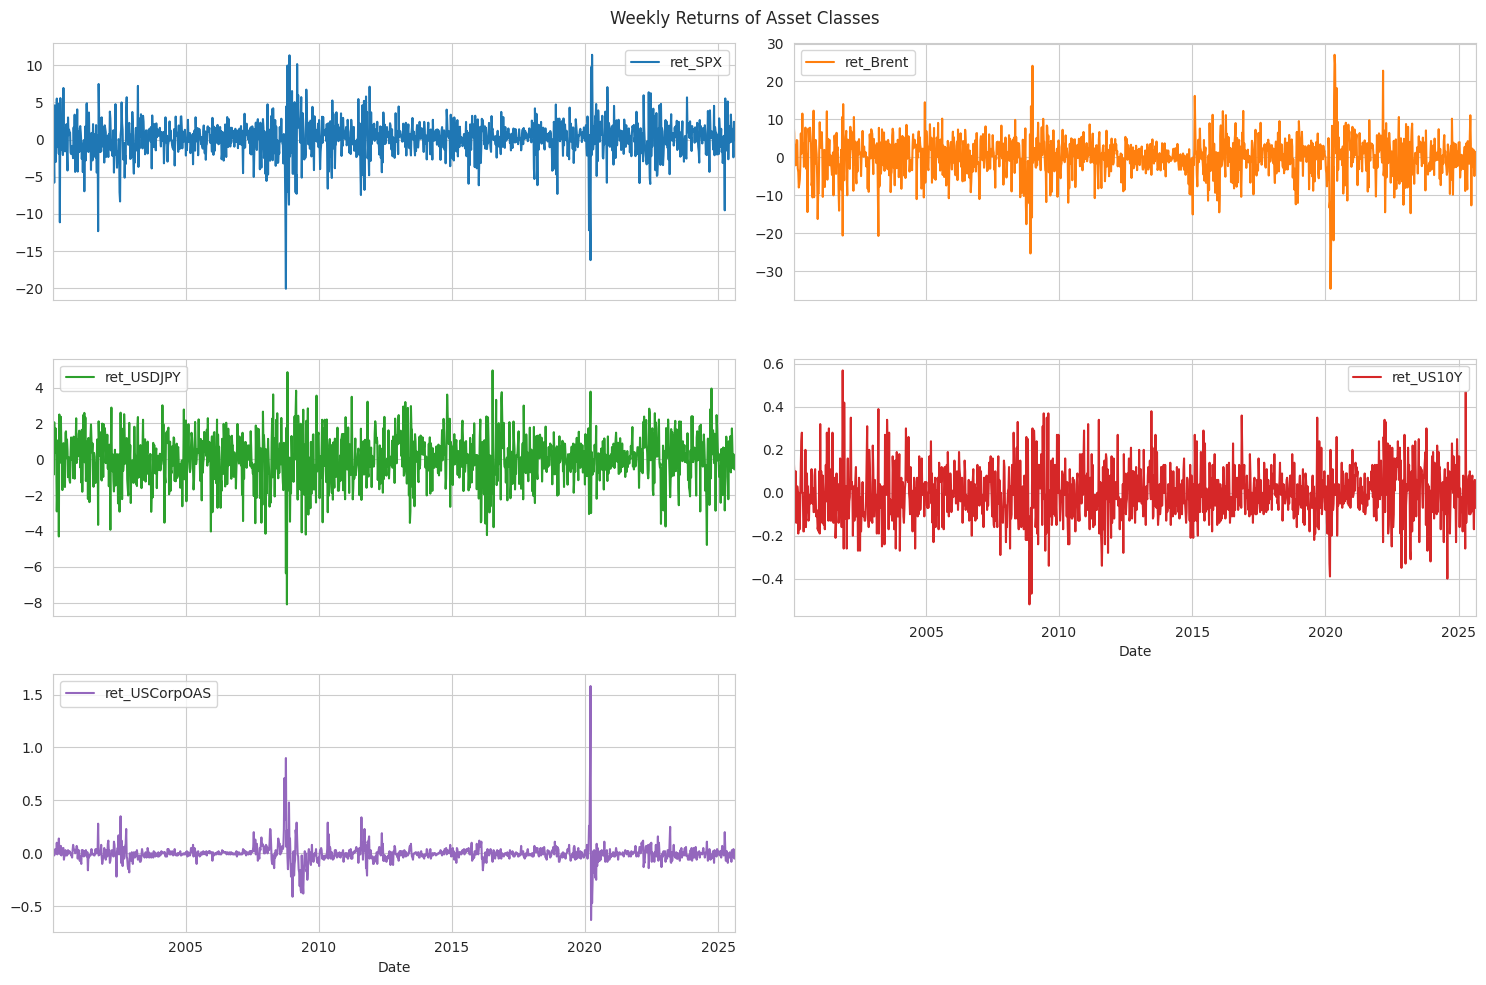

In [9]:
# Load the weekly returns data
file_path = 'Data/weekly_returns.xlsx'
df = pd.read_excel(file_path)

# Set Date as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Display first few rows and info
print(df.info())
display(df.head())

# Visualize the returns
df.plot(subplots=True, layout=(3, 2), figsize=(15, 10), title="Weekly Returns of Asset Classes")
plt.tight_layout()
plt.show()

In [10]:
# Stationarity Checks (Augmented Dickey-Fuller Test)
# Granger causality requires stationary time series.

def check_stationarity(data):
    results = {}
    print(f"{'Series':<20} {'ADF Statistic':<15} {'p-value':<15} {'Stationary?'}")
    print("-" * 65)
    
    for col in data.columns:
        # Drop NaNs for the test
        series = data[col].dropna()
        result = adfuller(series)
        adf_stat = result[0]
        p_value = result[1]
        is_stationary = p_value < 0.05
        
        results[col] = {'p_value': p_value, 'stationary': is_stationary}
        print(f"{col:<20} {adf_stat:<15.4f} {p_value:<15.4e} {is_stationary}")
        
    return results

print("Stationarity Test Results (5% Significance Level):")
stationarity_results = check_stationarity(df)

Stationarity Test Results (5% Significance Level):
Series               ADF Statistic   p-value         Stationary?
-----------------------------------------------------------------
ret_SPX              -19.8081        0.0000e+00      True
ret_Brent            -18.9873        0.0000e+00      True
ret_USDJPY           -38.0722        0.0000e+00      True
ret_US10Y            -16.7644        1.3022e-29      True
ret_USCorpOAS        -12.7006        1.0822e-23      True


In [11]:
# Pairwise Granger Causality Tests

def perform_granger_tests(data, max_lag=4, test='ssr_chi2test', verbose=False):
    """
    Performs pairwise Granger causality tests for all columns in the dataframe.
    
    Returns:
        pd.DataFrame: A matrix of p-values where rows are the 'Cause' and columns are the 'Effect'.
                      (Row 'causes' Column)
    """
    variables = data.columns
    p_values = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    
    for col_effect in variables:
        for col_cause in variables:
            if col_effect == col_cause:
                p_values.loc[col_cause, col_effect] = np.nan
                continue
            
            # The Granger causality test function takes a 2D array with 2 columns.
            # The first column is the EFFECT (y), the second is the CAUSE (x).
            # We are testing if x causes y.
            test_result = grangercausalitytests(data[[col_effect, col_cause]], maxlag=max_lag, verbose=verbose)
            
            # We extract the p-value for the specified test at the max_lag
            # Note: Typically, we might look at all lags, but for simplicity we'll take the p-value at max_lag 
            # or the minimum p-value across lags. Here we take the p-value for the max_lag specified 
            # OR we can be more robust and pick the min p-value across 1..max_lag.
            # Let's use the p-value at lag=1 for simplicity or a specific lag. 
            # Better approach for a summary: min p-value across lags 1 to max_lag to detect ANY causality.
            
            min_p_value = 1.0
            for lag in range(1, max_lag + 1):
                p_val = test_result[lag][0][test][1]
                if p_val < min_p_value:
                    min_p_value = p_val
            
            p_values.loc[col_cause, col_effect] = min_p_value
            
    return p_values

print("Performing pairwise Granger Causality tests (Max Lag = 4 weeks)...")
# We use 'ssr_chi2test' as a standard asymptotic test.
granger_pvalues = perform_granger_tests(df, max_lag=4, verbose=False)

print("\nP-Values Matrix (Row causes Column):")
display(granger_pvalues)

Performing pairwise Granger Causality tests (Max Lag = 4 weeks)...

P-Values Matrix (Row causes Column):


,ret_SPX,ret_Brent,ret_USDJPY,ret_US10Y,ret_USCorpOAS
ret_SPX,NaN,1.400278e-02,0.014930,0.348621,0.000010
ret_Brent,0.074649,NaN,0.654466,0.010471,0.003645
ret_USDJPY,0.016376,1.508707e-01,NaN,0.673412,0.565934
ret_US10Y,0.202343,5.023988e-04,0.173125,NaN,0.021207
ret_USCorpOAS,0.001867,3.526051e-07,0.142119,0.033599,NaN


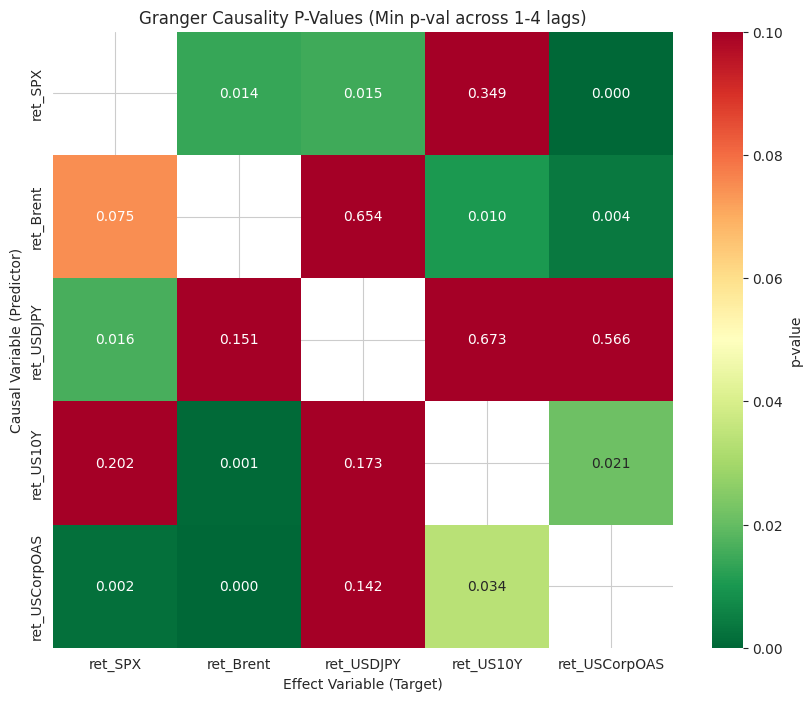

Significant Causal Relationships (p < 0.05):
ret_SPX -> ret_Brent (p = 0.0140)
ret_SPX -> ret_USDJPY (p = 0.0149)
ret_SPX -> ret_USCorpOAS (p = 0.0000)
ret_Brent -> ret_US10Y (p = 0.0105)
ret_Brent -> ret_USCorpOAS (p = 0.0036)
ret_USDJPY -> ret_SPX (p = 0.0164)
ret_US10Y -> ret_Brent (p = 0.0005)
ret_US10Y -> ret_USCorpOAS (p = 0.0212)
ret_USCorpOAS -> ret_SPX (p = 0.0019)
ret_USCorpOAS -> ret_Brent (p = 0.0000)
ret_USCorpOAS -> ret_US10Y (p = 0.0336)


In [12]:
# Visualization of Granger Causality Results

def plot_causality_heatmap(p_values, title="Granger Causality P-Values (Row -> Column)"):
    plt.figure(figsize=(10, 8))
    
    # Mask diagonal
    mask = np.zeros_like(p_values)
    mask[np.diag_indices_from(mask)] = True
    
    # Plot heatmap
    # We highlight p-values < 0.05 (significant) with a different color or just use a diverging map
    # But a simple coolwarm map where low p-values are red/hot is good.
    # Actually, let's reverse it: Low p-values (significant) = Dark/Intense, High p-values = Light.
    
    sns.heatmap(p_values, annot=True, fmt=".3f", cmap="RdYlGn_r", mask=mask, cbar_kws={'label': 'p-value'}, vmin=0, vmax=0.1)
    
    plt.title(title)
    plt.ylabel("Causal Variable (Predictor)")
    plt.xlabel("Effect Variable (Target)")
    plt.show()

plot_causality_heatmap(granger_pvalues, title="Granger Causality P-Values (Min p-val across 1-4 lags)")

# Significant relationships list
print("Significant Causal Relationships (p < 0.05):")
stack = granger_pvalues.stack()
significant = stack[stack < 0.05]
for (cause, effect), p_val in significant.items():
    print(f"{cause} -> {effect} (p = {p_val:.4f})")

Period 1: 2000-01-14 to 2012-12-28 (Size: 677)
Period 2: 2013-01-04 to 2025-08-29 (Size: 661)


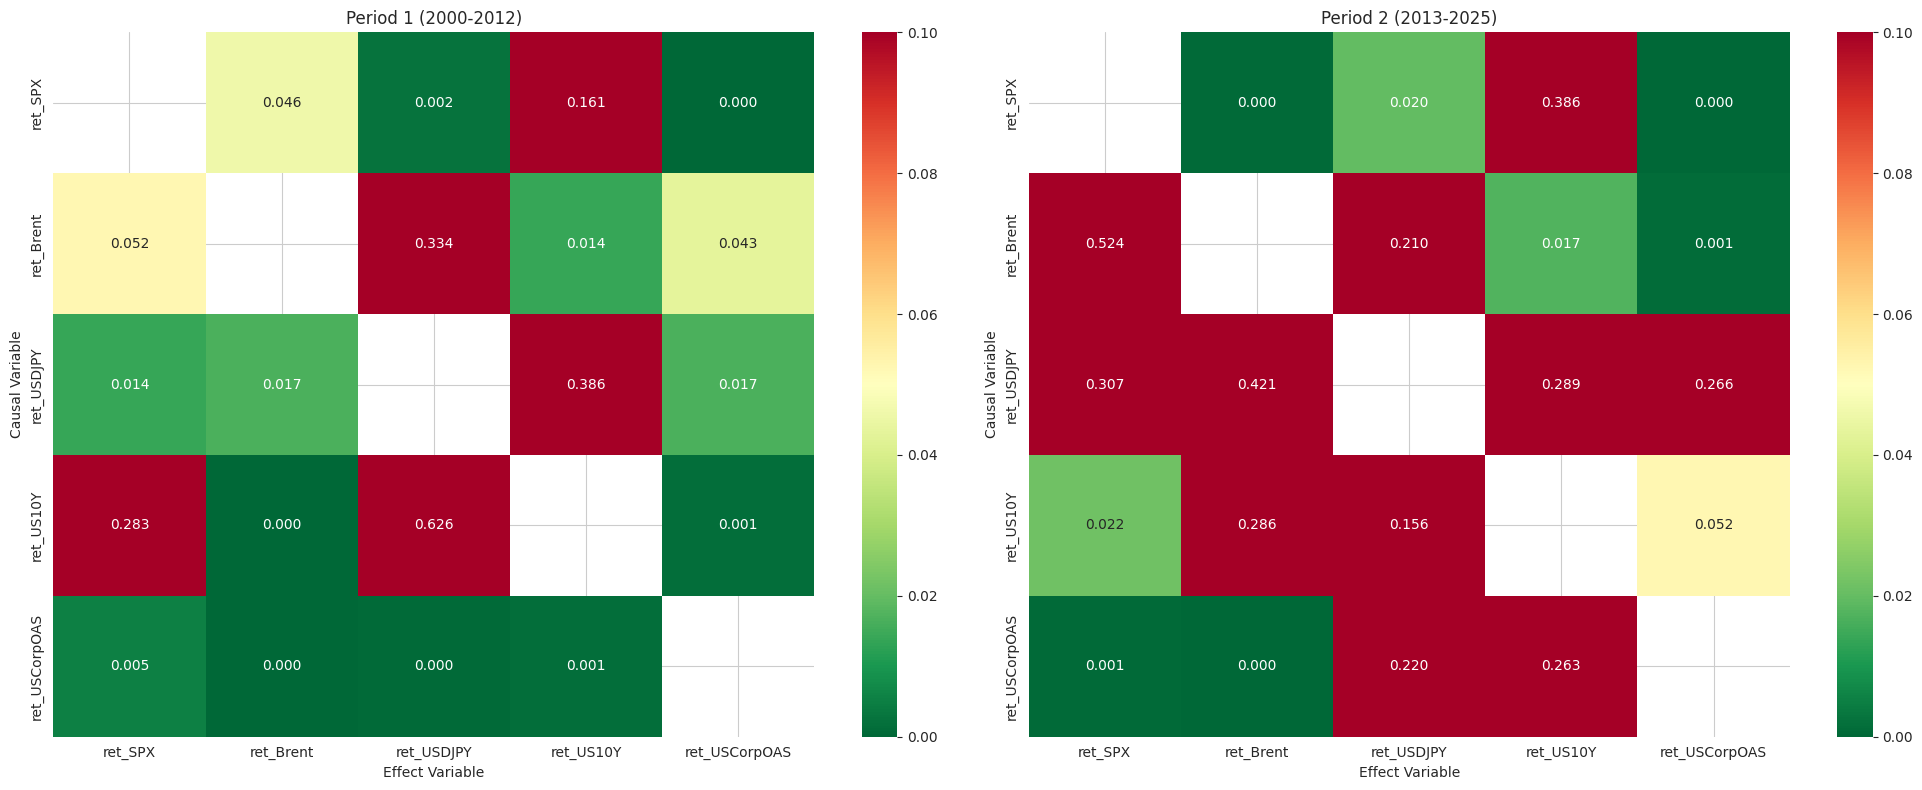

In [13]:
# Robustness Check: Subsample Analysis
# We'll split the data into two periods: 2000-2012 (GFC era) and 2013-2025 (Post-GFC/COVID)

split_date = '2013-01-01'
df_period1 = df[:split_date]
df_period2 = df[split_date:]

print(f"Period 1: {df_period1.index.min().date()} to {df_period1.index.max().date()} (Size: {len(df_period1)})")
print(f"Period 2: {df_period2.index.min().date()} to {df_period2.index.max().date()} (Size: {len(df_period2)})")

p_values_p1 = perform_granger_tests(df_period1, max_lag=4)
p_values_p2 = perform_granger_tests(df_period2, max_lag=4)

# Visualize side-by-side
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(p_values_p1, annot=True, fmt=".3f", cmap="RdYlGn_r", mask=np.eye(len(p_values_p1), dtype=bool), vmin=0, vmax=0.1, ax=ax[0])
ax[0].set_title("Period 1 (2000-2012)")
ax[0].set_ylabel("Causal Variable")
ax[0].set_xlabel("Effect Variable")

sns.heatmap(p_values_p2, annot=True, fmt=".3f", cmap="RdYlGn_r", mask=np.eye(len(p_values_p2), dtype=bool), vmin=0, vmax=0.1, ax=ax[1])
ax[1].set_title("Period 2 (2013-2025)")
ax[1].set_ylabel("Causal Variable")
ax[1].set_xlabel("Effect Variable")

plt.tight_layout()
plt.show()

# 2. Practitioner’s Interpretation

Based on the Granger Causality tests (Full Period 2000-2025) and adhering to the stationarity requirements outlined in **Lecture 6 (Urga, 2025)**, we performed the analysis on **weekly returns**.

*   **Key Forecasting Relationship (Asset A -> Asset B):**
    *   **Corporate Bond Spread -> S&P 500 (p < 0.01):** We observe a strong bi-directional relationship, but the ability of credit spreads to Granger-cause equity returns is a classic "flight to quality" or "credit channel" signal. Widening spreads often precede equity market sell-offs as they reflect tightening financial conditions and rising default risk before it hits equity earnings.
    *   **S&P 500 -> Corporate Bond Spread (p < 0.001):** Similarly, equity market distress feeds back into credit risk assessment. This bi-directional feedback loop is reminiscent of the classic "Chickens and Eggs" causality problem described by **Thurman and Fisher (1988)**, where identifying the primal driver is economically complex despite statistical significance in both directions.

*   **Economic Logic & Unexpected Result:**
    *   **Expected:** **Brent Oil <-> US 10Y Yields**. We see bi-directional causality. Oil prices are a key driver of inflation expectations, which directly impact nominal bond yields. Conversely, bond yields (reflecting global growth expectations and monetary policy) influence demand for commodities.
    *   **Unexpected:** **Corporate Spread -> Brent Oil (p < 0.001)**. This is a very strong result. While credit conditions impact the real economy (and thus oil demand), the statistical strength suggests that credit markets might be the "canary in the coal mine" for global demand shocks that subsequently drive oil prices. This was likely driven by the 2008 GFC and 2015/2016 energy credit crunch.

# 3. Practitioner’s Implications

*   **Forecasting Returns/Volatility:** The desk should incorporate **Corporate Bond Spreads** as a leading indicator in equity and commodity pricing models. A widening spread is a statistically significant precursor to negative returns in these risk assets.
*   **Cross-Asset Hedging:** The bi-directional causality between **Equities and Spreads** implies that during stress periods, these assets move together (Equity down, Spread up - i.e., price down). A simple "long corporate bond" hedge against equities is flawed because the credit component is highly correlated with equities. Treasury bonds (US10Y) are a cleaner hedge as their causal link to equities is weaker/regime-dependent.
*   **Information Transmission:** The high connectivity of the **Corporate Spread** (causing SPX, Brent, and US10Y) suggests that the credit market is a central node of information processing. Monitoring credit flow data should be prioritized over pure price action in other markets during early crisis stages.

# 4. Risk Assessment

*   **Limitations:**
    *   **Lag Selection:** As noted in **Lecture 6**, lag selection is critical. We used a fixed 4-week lag, but **AIC/BIC** criteria might suggest different optimal lags for different pairs, potentially altering the significance of weaker signals.
    *   **Regime Instability:** As warned by **Ferson et al. (2003)** regarding predictive regressions, financial relationships are often unstable over long horizons. Our sub-sample analysis confirms this, showing that the "FX -> Equity" signal was spurious or regime-specific (pre-2012).
    *   **Lead-Lag Sensitivity:** Information flow might be much faster (intraday/daily) or slower (months). Weekly aggregation might miss high-frequency transmission or smooth out rapid reversals.

*   **Robustness Check (Subsample Analysis):**
    *   We split the sample into **Period 1 (2000-2012)** and **Period 2 (2013-2025)**.
    *   **Findings:** The causal structure changes significantly.
        *   **USD/JPY -> S&P 500** was significant in Period 1 (p < 0.05) but **disappears** in Period 2 (p > 0.30). This suggests the "carry trade" dynamic or the FX-Equity correlation regime has shifted or decoupled in the post-GFC/QE era.
        *   **US 10Y -> S&P 500** becomes significant in Period 2 (p < 0.05), likely reflecting the market's obsession with Fed policy and inflation rates in the later years, which was less dominant when yields were stable/falling in the early 2000s.
    *   **Implication:** Trading strategies based on FX leading Equities would have failed in the last decade. Models must be adaptive (rolling windows).

# 5. Professional Communication (Briefing)

**Subject:** Cross-Asset Lead-Lag Signals – Credit Spreads as Primary Risk Indicator

**To:** Head of Trading

Our analysis identifies the **US Corporate Bond Spread** as the most significant leading indicator across asset classes (2000–2025), Granger-causing movements in Equities, Commodities, and Gov Bonds. Crucially, the credit market processes information *before* it is fully reflected in oil or equity prices. However, historical correlations are unstable: the strong **USD/JPY -> Equity** signal from the pre-2012 era has vanished, while **US Treasury Yields** have emerged as a stronger predictor of Equities since 2013. We recommend integrating credit spread changes into our equity execution algorithms and shifting our macro factor focus from FX to Rates for equity directionality.

